# sourcing the data

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import math
import json

from plots.utils import load_sledge_data, prepare_step_data

plt.style.use("./plots/latex_style.mplstyle")

benches = ["ROVER", "Hydra", "Alive", "Cadence"]

RESULTS_DIR = Path("../results")
RESULTS_DIR_ALT = Path("../benchmarks/results")

BENCH_BASE = Path("../benchmarks")

FIGURES_PATH = RESULTS_DIR / "plots"

TABLE_OUTPUT = RESULTS_DIR / 'tables'

TIMEOUT = 60_000  # timeout in milliseconds

os.makedirs(FIGURES_PATH, exist_ok=True)

parabit = {}
pbv = {}

pbv["Alive"] = pd.read_csv(f"{RESULTS_DIR_ALT}/solver/alive_smt2/results.csv")
pbv["Hydra"] = pd.read_csv(f"{RESULTS_DIR_ALT}/solver/hydra_smt2/results.csv")
pbv["Cadence"] = pd.read_csv(f"{RESULTS_DIR_ALT}/solver/Cadence_smt2/summary.csv")
pbv["ROVER"] = pd.read_csv(f"{RESULTS_DIR_ALT}/solver/rover_smt2/summary.csv")

for bench in benches:
    parabit[bench] = pd.read_csv(f"{RESULTS_DIR}/parabit/{bench}/results.csv")
    parabit[bench]["time_taken"] = (
        parabit[bench]["time_taken"] * 1000
    )  # convert seconds to milliseconds
    parabit[bench]["file"] = parabit[bench]["file"].str.replace(
        ".bwlang", "", regex=False
    )  # remove file extension
    if bench == "Hydra":
        parabit[bench]["file"] = parabit[bench]["file"].str.replace(
            "hydra_", "", regex=False
        )  # remove file extension
    parabit[bench].set_index("file")
    pbv[bench]["file"] = pbv[bench]["file"].str.replace(
        ".smt2", "", regex=False
    )  # remove file extension
    pbv[bench].set_index("file")

# pbv, parabit, mirabelle

In [2]:
datas = {}
for i, bench in enumerate(benches):
    all_names = set(parabit[bench]["file"]) | set(pbv[bench]["file"])

    data = pd.DataFrame()

    data["name"] = [x for x in all_names if type(x) is str]

    print(bench, len(data["name"]))

    if bench in ["Hydra", "Alive"]:
        filtered = pbv[bench][["time", "file", "result"]]
    else:
        filtered = pbv[bench][["unsat_time_average", "file", "result"]]
        filtered = filtered.rename(columns={"unsat_time_average": "time"})

    filtered["time"] *= 1000  # convert second to ms
    data = data.merge(filtered, left_on="name", right_on="file", how="left")
    data = data.rename(columns={"time": "pbv", "result": "pbv_result"}).drop(
        columns="file"
    )
    data["pbv_result"] = data["pbv_result"].map(
        {"unsat": True, "sat": False, "timeout": False, "error": False}
    )

    filtered = parabit[bench][["time_taken", "file", "status"]]
    data = data.merge(filtered, left_on="name", right_on="file", how="left")
    data = data.rename(
        columns={"time_taken": "parabit", "status": "parabit_result"}
    ).drop(columns="file")
    data["parabit_result"] = data["parabit_result"].map(
        {"SUCCESS": True, "FAILED": False}
    )

    # mir = mirabelle[bench]['nolemma'].set_index('name')
    # data['nolemma'] = mir['time'].where(mir['timeout'] == False)
    datas[bench] = data

datas["Hydra"]

ROVER 28
Hydra 154
Alive 200
Cadence 5


,name,pbv,pbv_result,parabit,parabit_result
0,opt_3058,19.702673,True,NaN,NaN
1,opt_2903,60000.000000,False,NaN,NaN
2,opt_2744,61.487198,True,0.483537,True
3,opt_862,60000.000000,False,25780.000000,False
4,opt_263,28.799057,True,7.204918,True
...,...,...,...,...,...
149,opt_293,35.049677,True,1.362750,True
150,opt_1250,25.069952,True,NaN,NaN
151,opt_3244,21.609783,True,NaN,NaN
152,opt_1248,60000.000000,False,NaN,NaN


In [3]:
single_width = {}
multi_width = {}

for bench in benches:
    single_filename = BENCH_BASE / bench / "singlewidth.txt"
    with open(single_filename, "r") as f:
        filter_values = [l.strip() for l in f.readlines()]
        single_width[bench] = set(filter_values)

    multi_filename = BENCH_BASE / bench / "multiwidth.txt"
    with open(multi_filename, "r") as f:
        filter_values = [l.strip() for l in f.readlines()]
        multi_width[bench] = set(filter_values)

single = {
    "benchmark": ["unique", "solved", "total"],
    "pbv_full": [],
    "pbv_restricted": [],
    "parabit": [],
    "vbs": [],
}
multi = {
    "benchmark": ["unique", "solved", "total"],
    "pbv_full": [],
    "pbv_restricted": [],
    "parabit": [],
    "vbs": [],
}

for table in [single, multi]:
    for k in table:
        if k != "benchmark":
            table[k] = [0, 0, 0]

for bench in ["Alive", "Hydra", "ROVER", "Cadence"]:
    data = datas[bench]
    sw = data["name"].isin(single_width[bench])
    mw = data["name"].isin(multi_width[bench])

    pb = ~data["parabit_result"].isna()
    pbv = ~data["pbv_result"].isna()
    restricted = pb & pbv
    both = (data["parabit_result"] & pb) | (data["pbv_result"] & pbv)

    single["benchmark"].append(bench)
    single["pbv_full"].append(
        f"{len(data[sw & data['pbv_result'] & pbv])}/{len(data[sw & pbv])}"
    )
    single["pbv_full"][2] += len(data[sw & pbv])
    single["pbv_full"][1] += len(data[sw & pbv & data["pbv_result"]])
    single["pbv_full"][0] += len(
        data[sw & data["pbv_result"] & (data["parabit_result"] != True)]
    )

    single["pbv_restricted"].append(
        f"{len(data[sw & data['pbv_result'] & restricted])}/{len(data[sw & restricted])}"
    )
    single["pbv_restricted"][2] += len(data[sw & restricted])
    single["pbv_restricted"][1] += len(data[sw & restricted & data["pbv_result"]])
    single["pbv_restricted"][0] += len(
        data[sw & restricted & data["pbv_result"] & (data["parabit_result"] != True)]
    )

    single["parabit"].append(
        f"{len(data[sw & data['parabit_result'] & pb])}/{len(data[sw & pb])}"
    )
    single["parabit"][2] += len(data[sw & pb])
    single["parabit"][1] += len(data[sw & data["parabit_result"] & pb])
    single["parabit"][0] += len(
        data[sw & data["parabit_result"] & pb & (data["pbv_result"] != True)]
    )

    single["vbs"].append(f"{len(data[sw & both])}/{len(data[sw])}")
    single["vbs"][2] += len(data[sw])
    single["vbs"][1] += len(data[sw & both])

    multi["benchmark"].append(bench)

    multi["pbv_full"].append(
        f"{len(data[mw & data['pbv_result'] & pbv])}/{len(data[mw & pbv])}"
    )
    multi["pbv_full"][2] += len(data[mw & pbv])
    multi["pbv_full"][1] += len(data[mw & pbv & data["pbv_result"]])
    multi["pbv_full"][0] += len(
        data[mw & data["pbv_result"] & (data["parabit_result"] != True)]
    )

    multi["pbv_restricted"].append(
        f"{len(data[mw & data['pbv_result'] & restricted])}/{len(data[mw & restricted])}"
    )
    multi["pbv_restricted"][2] += len(data[mw & restricted])
    multi["pbv_restricted"][1] += len(data[mw & restricted & data["pbv_result"]])
    multi["pbv_restricted"][0] += len(
        data[mw & restricted & data["pbv_result"] & (data["parabit_result"] != True)]
    )

    multi["parabit"].append(
        f"{len(data[mw & data['parabit_result'] & pb])}/{len(data[mw & pb])}"
    )
    multi["parabit"][2] += len(data[mw & pb])
    multi["parabit"][1] += len(data[mw & data["parabit_result"] & pb])
    multi["parabit"][0] += len(
        data[mw & data["parabit_result"] & pb & (data["pbv_result"] != True)]
    )

    multi["vbs"].append(f"{len(data[mw & both])}/{len(data[mw])}")
    multi["vbs"][2] += len(data[mw])
    multi["vbs"][1] += len(data[mw & both])

for table in [single, multi]:
    table['vbs'][0] = '-'
    for key in table:
        if key != "benchmark":
            table[key][1] = f"{table[key][1]/table[key][2]:.0%}"
        table[key].pop(2)
        table[key].append(table[key].pop(0))
        table[key].append(table[key].pop(0))

single_df = pd.DataFrame(single)
multi_df = pd.DataFrame(multi)

display(single_df)
display(multi_df)

,benchmark,pbv_full,pbv_restricted,parabit,vbs
0,Alive,104/196,31/61,57/61,131/196
1,Hydra,55/74,26/30,24/30,56/74
2,ROVER,3/3,3/3,2/3,3/3
3,Cadence,2/4,2/4,3/4,4/4
4,unique,108,6,30,-
5,solved,59%,63%,88%,70%


,benchmark,pbv_full,pbv_restricted,parabit,vbs
0,Alive,3/4,0/1,1/1,4/4
1,Hydra,33/75,9/40,32/40,56/75
2,ROVER,7/24,7/24,25/25,25/25
3,Cadence,0/1,0/1,1/1,1/1
4,unique,27,0,43,-
5,solved,41%,24%,88%,82%


In [4]:
# Save tables

table2_path = TABLE_OUTPUT / 'table2'
table2_path.mkdir(parents=True, exist_ok=True)
with open( table2_path / 'single.tex', 'w+') as f:
    single_df.to_latex(f, index=False)

with open( table2_path / 'multiple.tex', 'w+') as f:
    multi_df.to_latex(f, index=False)

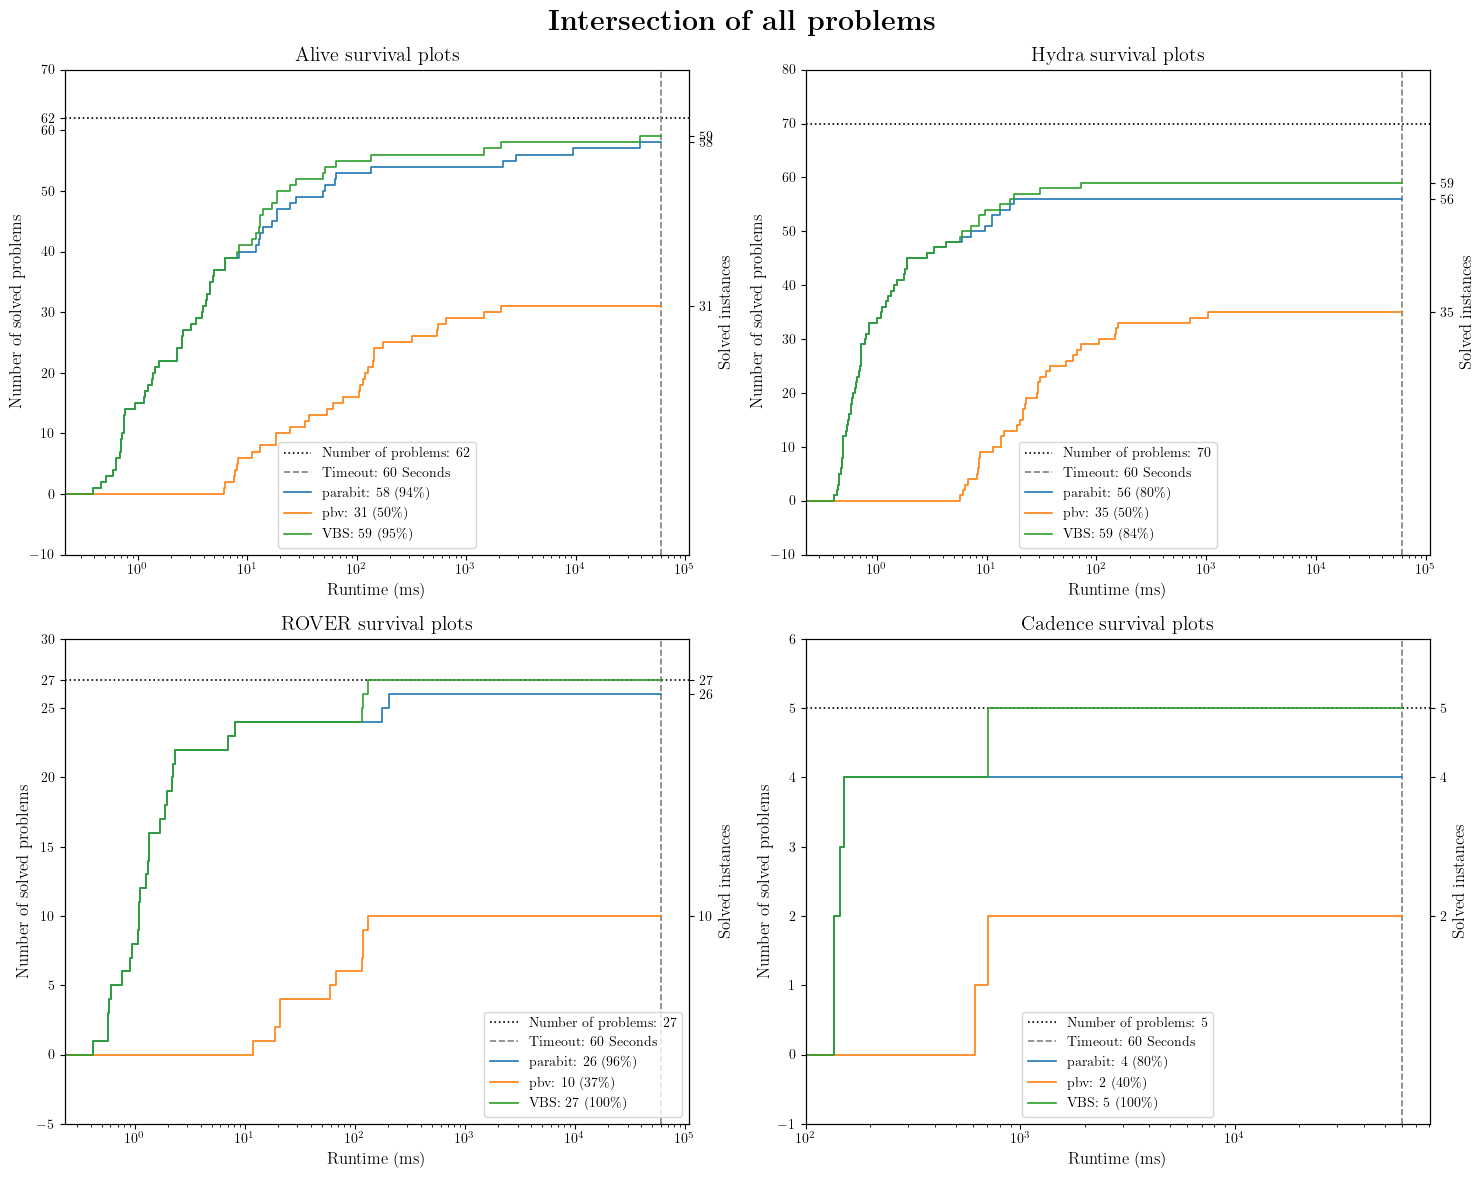

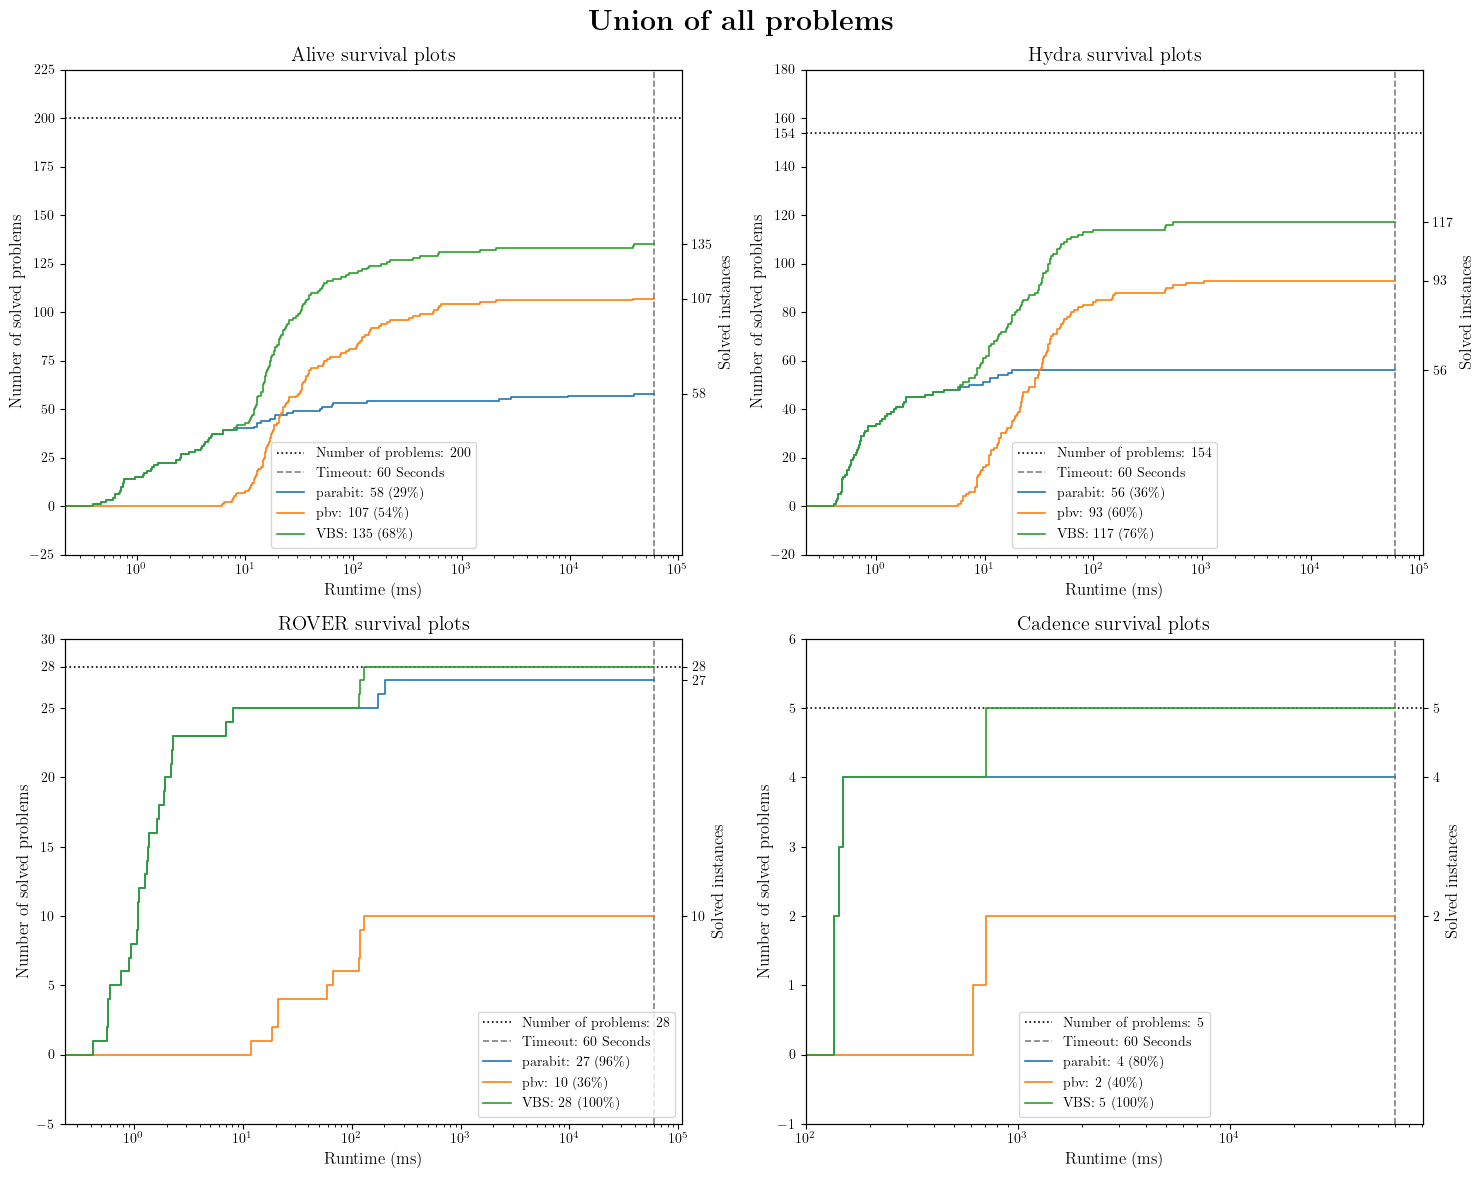

In [5]:
from plots.utils import combine_results, plot_cactus

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
for ax_i, i in enumerate([2, 1, 0, 3]):
    bench = list(datas.keys())[i]
    data = datas[bench]
    data_tmp = data.copy()

    filter_frame = ~data_tmp['parabit_result'].isna() & ~data_tmp['pbv_result'].isna()
    data_tmp = data_tmp[filter_frame]
    
    data_tmp['parabit'] = data_tmp[data_tmp['parabit_result']]['parabit']
    data_tmp['pbv'] = data_tmp[data_tmp['pbv_result']]['pbv']
    
    data_tmp = data_tmp[['parabit', 'pbv']]

    data_tmp["VBS"] = data_tmp.apply(combine_results, axis=1)

    ax = axs[ax_i // 2][ax_i % 2]
    plot_cactus(ax, data_tmp, TIMEOUT)
    ax.legend(loc="best")
    ax.set_title(f"{bench} survival plots")
fig.suptitle("\\textbf{Intersection of all problems}", fontsize="xx-large")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "Figure7.pdf")
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
for ax_i, i in enumerate([2, 1, 0, 3]):
    bench = list(datas.keys())[i]
    data = datas[bench]
    data_tmp = data.copy()

    filter_frame = ~data_tmp['parabit_result'].isna() | ~data_tmp['pbv_result'].isna()
    data_tmp = data_tmp[filter_frame]
    
    data_tmp['parabit'] = data_tmp[~data_tmp['parabit_result'].isna() & data_tmp['parabit_result']]['parabit']
    data_tmp['pbv'] = data_tmp[~data_tmp['pbv_result'].isna() & data_tmp['pbv_result']]['pbv']
    
    data_tmp = data_tmp[['parabit', 'pbv']]

    data_tmp["VBS"] = data_tmp.apply(combine_results, axis=1)

    ax = axs[ax_i // 2][ax_i % 2]
    plot_cactus(ax, data_tmp, TIMEOUT)
    ax.legend(loc="best")
    ax.set_title(f"{bench} survival plots")
fig.suptitle("\\textbf{Union of all problems}", fontsize="xx-large")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "Figure7_allproblems.pdf")
plt.show()

In [28]:
# Generate Table 3

data_out = {"benchmark" : [], "#_parabit": [], "Nodes" : [], "Classes": [], "Iterations": [], "Time(ms)": [], "#_pbv": [], "PBV_Time(ms)":[]}

for bench in benches:
    data = datas[bench]
    solved_problems_mask = ~data['parabit_result'].isna() & data['parabit_result']
    solved_problems = data[solved_problems_mask]['name'].tolist()
    
    iterations_acc = 0
    eclass_acc = 0
    enode_acc = 0
    
    for prob in solved_problems:
        stats_file = RESULTS_DIR / 'parabit' / bench / 'logs' / f"{prob}.bwlang.stats.json"
        with open(stats_file, 'r') as f:
            stats = json.load(f)
            iterations_acc += stats[1]['summary']['iterations']
            enode_acc += stats[1]['summary']['egraph_nodes']
            eclass_acc += stats[1]['summary']['egraph_classes']
    
    iterations_avg = iterations_acc / len(solved_problems)
    eclass_avg = eclass_acc / len(solved_problems)
    enode_avg = enode_acc / len(solved_problems)

    parabit_time_avg = data[solved_problems_mask]['parabit'].sum() / len(data[solved_problems_mask])
    pbv_time_avg = data[(mask := (~data['pbv_result'].isna() & data['pbv_result']))]['pbv'].sum() / len(data[mask])
    
    data_out['benchmark'].append(f'{bench} ({len(data)})')
    data_out['Nodes'].append(f"{enode_avg:.0f}")
    data_out['Classes'].append(f"{eclass_avg:.0f}")
    data_out['Iterations'].append(f"{iterations_avg:.2f}")
    data_out['Time(ms)'].append(f"{parabit_time_avg:.0f}")
    data_out['#_parabit'].append(len(data[solved_problems_mask]))
    data_out['#_pbv'].append(len(data[mask]))
    data_out['PBV_Time(ms)'].append(f"{pbv_time_avg:.0f}")

table_df = pd.DataFrame(data_out)
table_df

,benchmark,#_parabit,Nodes,Classes,Iterations,Time(ms),#_pbv,PBV_Time(ms)
0,ROVER (28),27,1101,488,4.00,16,10,68
1,Hydra (154),56,443,177,3.93,3,93,65
2,Alive (200),58,23027,7509,5.53,933,107,470
3,Cadence (5),4,11556,4942,7.50,141,2,662
